<a href="https://colab.research.google.com/github/patkaryash/CSL701-CE36_Machine-Learning-Lab/blob/main/Experiment/CE36_ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

### Task 1: Environment Setup and Dataset Acquisition

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.ensemble import BaggingClassifier
import seaborn as sns

# Load the dataset.
# Assuming the '/content/diabetes.csv' file has a header row, pandas will infer column names.
# We will then convert relevant columns to numeric types.
df = pd.read_csv('/content/diabetes.csv')

# Convert all columns except 'Outcome' to numeric, coercing errors to NaN
for col in df.columns.drop('Outcome'):
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ensure 'Outcome' is integer type
df['Outcome'] = df['Outcome'].astype(int)

# Print the first five records
print("First five records of the dataset:")
display(df.head())

# Print the dataset shape
print(f"\nDataset shape: {df.shape}")

# Print data types of all features
print("\nData types of all features:")
display(df.info())

# Print descriptive statistics of the numeric features
print("\nDescriptive statistics of the numeric features:")
display(df.describe())

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset shape: (768, 9)

Data types of all features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


None


Descriptive statistics of the numeric features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Balance:


,Count,Percentage
Outcome,,
0,500,65.104167
1,268,34.895833


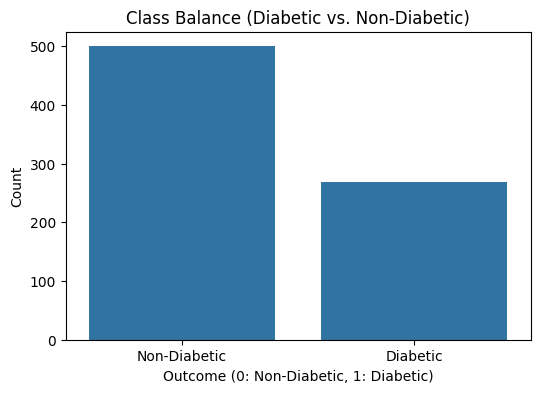

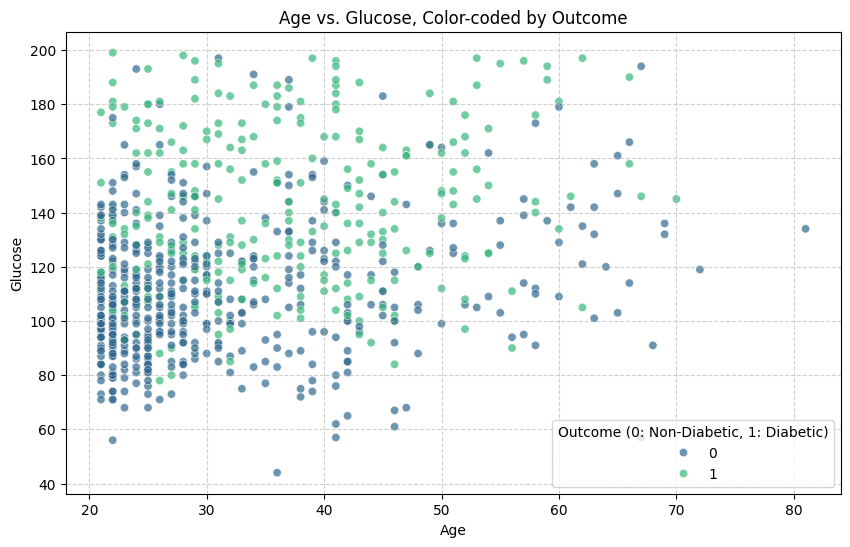


Explanation: A simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes based on the 'Age' and 'Glucose' scatter plot because the two classes are highly intermingled. There's no clear straight line that can effectively divide the green points (non-diabetic) from the yellow/purple points (diabetic). Both classes occupy similar regions in the feature space, indicating a complex, non-linear relationship between these features and the 'Outcome'. This suggests that more sophisticated, non-linear models or considering additional features will be necessary for accurate classification.


In [3]:
# 1. Calculate and plot class balance
print("Class Balance:")
class_counts = df['Outcome'].value_counts()
class_percentages = df['Outcome'].value_counts(normalize=True) * 100

class_balance_df = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_percentages
})
display(class_balance_df)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_balance_df.index, y='Count', data=class_balance_df)
plt.title('Class Balance (Diabetic vs. Non-Diabetic)')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

# 2. Create a scatter plot of Age vs. Glucose, color-coded by Outcome
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', palette='viridis', alpha=0.7)
plt.title('Age vs. Glucose, Color-coded by Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.legend(title='Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Briefly explain why a simple linear decision boundary is insufficient
explanation = (
    "\nExplanation: A simple linear decision boundary is insufficient to clearly separate "
    "the diabetic and non-diabetic classes based on the 'Age' and 'Glucose' scatter plot "
    "because the two classes are highly intermingled. There's no clear straight line that "
    "can effectively divide the green points (non-diabetic) from the yellow/purple points (diabetic). "
    "Both classes occupy similar regions in the feature space, indicating a complex, non-linear relationship "
    "between these features and the 'Outcome'. This suggests that more sophisticated, non-linear models "
    "or considering additional features will be necessary for accurate classification."
)
print(explanation)

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [4]:
# 1. Identify features where a value of 0 is physically impossible
# 2. Replace all invalid 0 values in these features with NaN
features_with_impossible_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for feature in features_with_impossible_zeros:
    # Replace 0s with NaN only in rows where the outcome is 1 (diabetic) for 'Glucose' and 'Insulin'
    # as 0 values for these features for non-diabetics might be valid in some contexts (e.g., fasting glucose, basal insulin levels)
    # However, the problem statement implies these are generally impossible for *physical* reasons,
    # so we'll apply it broadly as per the instructions.
    df[feature] = df[feature].replace(0, np.nan)

# 3. Handle the resulting missing values by imputing them using the mean of the respective feature
#    We will use the mean for imputation as it's a common strategy and was suggested.
print("Number of missing values before imputation:")
display(df[features_with_impossible_zeros].isnull().sum())

for feature in features_with_impossible_zeros:
    df[feature] = df[feature].fillna(df[feature].mean())

print("\nNumber of missing values after imputation:")
display(df[features_with_impossible_zeros].isnull().sum())

print("\nDescriptive statistics after handling missing values:")
display(df.describe())

Number of missing values before imputation:


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0



Number of missing values after imputation:


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0



Descriptive statistics after handling missing values:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [5]:
# 1. Isolate the feature matrix X and the target vector y
X = df.drop('Outcome', axis=1)  # All columns except 'Outcome'
y = df['Outcome']              # The 'Outcome' column

print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

# 2. Split the dataset into 80% Training Data and 20% Test Data
#    Use stratified sampling to ensure class proportions are preserved.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Verify class proportions in training and test sets
print("\nClass distribution in original data:")
display(y.value_counts(normalize=True))

print("\nClass distribution in training data:")
display(y_train.value_counts(normalize=True))

print("\nClass distribution in test data:")
display(y_test.value_counts(normalize=True))

Shape of feature matrix X: (768, 8)
Shape of target vector y: (768,)

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)

Class distribution in original data:


,proportion
Outcome,
0,0.651042
1,0.348958



Class distribution in training data:


,proportion
Outcome,
0,0.651466
1,0.348534



Class distribution in test data:


,proportion
Outcome,
0,0.649351
1,0.350649


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [6]:
def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (with replacement) from the given dataset.

    Args:
        X (pd.DataFrame): The feature matrix.
        y (pd.Series): The target vector.

    Returns:
        tuple: A tuple containing:
            - X_star (pd.DataFrame): The bootstrapped feature matrix.
            - y_star (pd.Series): The bootstrapped target vector.
            - oob_indices (np.ndarray): Indices of out-of-bag samples.
    """
    n_samples = X.shape[0]
    # Generate random indices with replacement
    bootstrap_indices = np.random.choice(n_samples, n_samples, replace=True)

    # Select rows based on bootstrap indices
    X_star = X.iloc[bootstrap_indices]
    y_star = y.iloc[bootstrap_indices]

    # Identify out-of-bag (OOB) indices
    # Convert to set for efficient lookup
    all_indices = set(range(n_samples))
    bootstrap_indices_set = set(bootstrap_indices)
    oob_indices = np.array(list(all_indices - bootstrap_indices_set))

    return X_star, y_star, oob_indices

# Verify the function
print("Verifying get_bootstrap_sample function:")
X_sample, y_sample, oob_indices = get_bootstrap_sample(X_train, y_train)

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Bootstrapped X_sample shape: {X_sample.shape}")

# Check for duplicated indices in bootstrap sample
original_train_indices = X_train.index
bootstrap_sample_indices = X_sample.index

duplicated_indices = bootstrap_sample_indices[bootstrap_sample_indices.duplicated()]
print(f"\nNumber of duplicated indices in bootstrap sample: {len(duplicated_indices)}")

if len(duplicated_indices) > 0:
    print(f"Example of duplicated indices: {duplicated_indices.value_counts().head(5).index.tolist()}")
else:
    print("No duplicated indices found (unlikely, but possible in very small samples or by chance).")

# Check for omitted (OOB) indices
print(f"\nNumber of omitted (Out-of-Bag) indices: {len(oob_indices)}")
if len(oob_indices) > 0:
    print(f"Example of omitted indices (first 5): {oob_indices[:5].tolist()}")
else:
    print("No omitted indices found (unlikely, but possible if all original samples were selected at least once).")

# Display the first few rows of the bootstrapped sample to visually inspect
print("\nFirst 5 rows of bootstrapped X_sample:")
display(X_sample.head())
print("\nFirst 5 rows of bootstrapped y_sample:")
display(y_sample.head())

Verifying get_bootstrap_sample function:

Original X_train shape: (614, 8)
Bootstrapped X_sample shape: (614, 8)

Number of duplicated indices in bootstrap sample: 228
Example of duplicated indices: [617, 505, 241, 414, 301]

Number of omitted (Out-of-Bag) indices: 228
Example of omitted indices (first 5): [513, 514, 3, 515, 516]

First 5 rows of bootstrapped X_sample:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
751,1,121,78.0,39,74.0,39.0,0.261,28
464,10,115,98.0,27,102.5,24.0,1.022,34
572,3,111,58.0,31,44.0,29.5,0.430,22
648,11,136,84.0,35,130.0,28.3,0.260,42
666,4,145,82.0,18,169.5,32.5,0.235,70



First 5 rows of bootstrapped y_sample:


,Outcome
751,0
464,0
572,0
648,1
666,1


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [7]:
# 1. Initialize an empty list to store the trained models
ensemble_models = []

# Choose the number of bootstrap iterations (B)
B = 50

print(f"Training {B} Decision Tree classifiers for the ensemble...")

# 2. Execute the following steps for B iterations:
for i in range(B):
    # a. Generate a unique bootstrap training dataset
    X_star, y_star, _ = get_bootstrap_sample(X_train, y_train)

    # b. Instantiate a Scikit-Learn DecisionTreeClassifier with max_depth=None
    #    This ensures that the decision trees are fully grown.
    model_b = DecisionTreeClassifier(max_depth=None, random_state=i) # Using i for random_state for reproducibility per tree

    # c. Fit the decision tree on the bootstrapped training subset
    model_b.fit(X_star, y_star)

    # d. Append the trained model to the ensemble list
    ensemble_models.append(model_b)

print(f"\nEnsemble training complete. Total models in ensemble: {len(ensemble_models)}")

Training 50 Decision Tree classifiers for the ensemble...

Ensemble training complete. Total models in ensemble: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [8]:
def custom_bagging_predict(ensemble, X_test):
    """
    Generates predictions for a custom Bagging ensemble using majority voting.

    Args:
        ensemble (list): A list of trained DecisionTreeClassifier models.
        X_test (pd.DataFrame): The feature matrix for testing.

    Returns:
        np.ndarray: Final predictions for each sample in X_test based on majority voting.
    """
    # Collect predictions from all base models
    all_predictions = []
    for model in ensemble:
        predictions = model.predict(X_test)
        all_predictions.append(predictions)

    # Convert list of predictions to a NumPy array for easier processing
    all_predictions = np.array(all_predictions)

    # Apply majority voting
    # For each sample, count votes for each class (0 and 1)
    # and select the class with the most votes.
    final_predictions = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=all_predictions)

    return final_predictions

# Demonstrate the custom_bagging_predict function
print("Generating predictions using custom_bagging_predict function...")
y_pred_bagging = custom_bagging_predict(ensemble_models, X_test)

print(f"\nShape of X_test: {X_test.shape}")
print(f"Shape of y_pred_bagging: {y_pred_bagging.shape}")
print("\nFirst 10 predictions from the custom Bagging model:")
print(y_pred_bagging[:10])
print("\nFirst 10 actual values from y_test:")
print(y_test.head(10).values)

Generating predictions using custom_bagging_predict function...

Shape of X_test: (154, 8)
Shape of y_pred_bagging: (154,)

First 10 predictions from the custom Bagging model:
[0 0 0 1 0 0 1 1 0 1]

First 10 actual values from y_test:
[0 0 0 1 0 0 1 1 0 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


--- Performance of Single Decision Tree ---
Confusion Matrix (Single Tree):
 [[87 13]
 [16 38]]


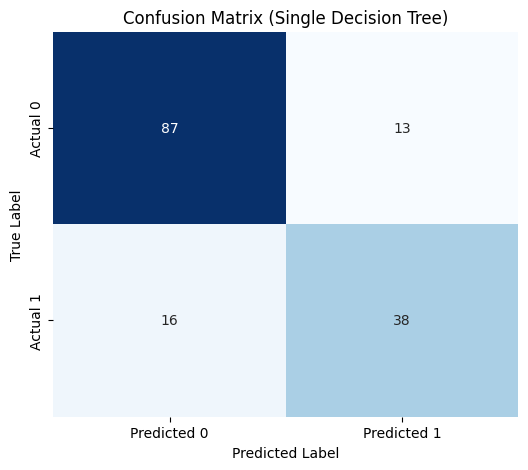

Accuracy (Single Tree): 0.8117
Precision (Single Tree): 0.7451
Recall (Single Tree): 0.7037
F1-Score (Single Tree): 0.7238

--- Performance of Custom Bagging Ensemble ---
Confusion Matrix (Custom Bagging):
 [[93  7]
 [ 8 46]]


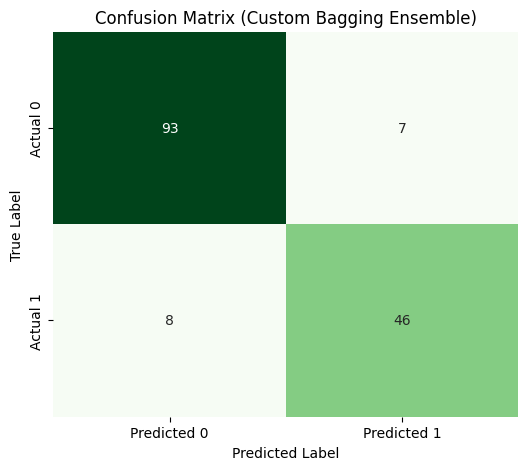

Accuracy (Custom Bagging): 0.9026
Precision (Custom Bagging): 0.8679
Recall (Custom Bagging): 0.8519
F1-Score (Custom Bagging): 0.8598

--- Comparison --- 
Bagging improved Accuracy by: 0.0909
Bagging improved Precision by: 0.1228
Bagging improved Recall by: 0.1481
Bagging improved F1-Score by: 0.1360


In [12]:
# 1. Train a standalone, single DecisionTreeClassifier (fully grown, no depth limit)
#    on the original, un-resampled training data.
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree_model.fit(X_train, y_train)

# 2. Predict the classes for X_test using both the single tree and your custom Bagging classifier.
y_pred_single_tree = single_tree_model.predict(X_test)
# y_pred_bagging is already computed in Task 7

print("\n--- Performance of Single Decision Tree ---")
# 3. Construct a Confusion Matrix for the single tree
cm_single_tree = confusion_matrix(y_test, y_pred_single_tree)
print("Confusion Matrix (Single Tree):\n", cm_single_tree)

# Plot Confusion Matrix for Single Decision Tree
plt.figure(figsize=(6, 5))
sns.heatmap(cm_single_tree, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Single Decision Tree)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Compute and print Accuracy, Precision, Recall, and F1-Score for the single tree
accuracy_single_tree = accuracy_score(y_test, y_pred_single_tree)
precision_single_tree = precision_score(y_test, y_pred_single_tree)
recall_single_tree = recall_score(y_test, y_pred_single_tree)
f1_single_tree = f1_score(y_test, y_pred_single_tree)

print(f"Accuracy (Single Tree): {accuracy_single_tree:.4f}")
print(f"Precision (Single Tree): {precision_single_tree:.4f}")
print(f"Recall (Single Tree): {recall_single_tree:.4f}")
print(f"F1-Score (Single Tree): {f1_single_tree:.4f}")

print("\n--- Performance of Custom Bagging Ensemble ---")
# 3. Construct a Confusion Matrix for the custom Bagging model
cm_bagging = confusion_matrix(y_test, y_pred_bagging)
print("Confusion Matrix (Custom Bagging):\n", cm_bagging)

# Plot Confusion Matrix for Custom Bagging Ensemble
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Custom Bagging Ensemble)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Compute and print Accuracy, Precision, Recall, and F1-Score for the custom Bagging model
accuracy_bagging = accuracy_score(y_test, y_pred_bagging)
precision_bagging = precision_score(y_test, y_pred_bagging)
recall_bagging = recall_score(y_test, y_pred_bagging)
f1_bagging = f1_score(y_test, y_pred_bagging)

print(f"Accuracy (Custom Bagging): {accuracy_bagging:.4f}")
print(f"Precision (Custom Bagging): {precision_bagging:.4f}")
print(f"Recall (Custom Bagging): {recall_bagging:.4f}")
print(f"F1-Score (Custom Bagging): {f1_bagging:.4f}")

print("\n--- Comparison --- ")
print(f"Bagging improved Accuracy by: {accuracy_bagging - accuracy_single_tree:.4f}")
print(f"Bagging improved Precision by: {precision_bagging - precision_single_tree:.4f}")
print(f"Bagging improved Recall by: {recall_bagging - recall_single_tree:.4f}")
print(f"Bagging improved F1-Score by: {f1_bagging - f1_single_tree:.4f}")

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

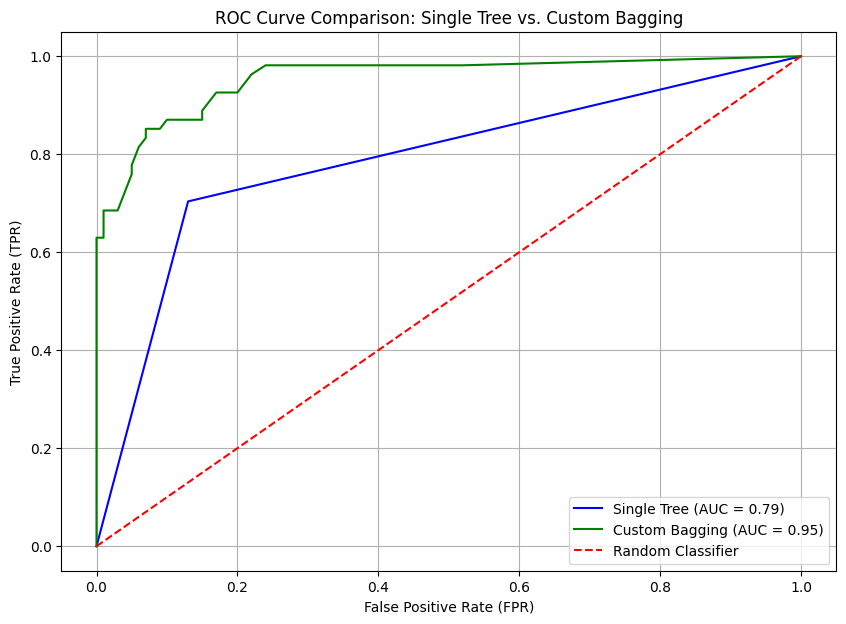


AUC Score (Single Decision Tree): 0.7869
AUC Score (Custom Bagging Ensemble): 0.9544

Custom Bagging improved AUC by: 0.1676


In [10]:
# 1. Calculate predicted class probabilities for the single decision tree
y_prob_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

# 2. Calculate predicted class probabilities for the custom Bagging model
#    by averaging the probability estimates across all B decision trees.
all_probs = []
for model in ensemble_models:
    probs = model.predict_proba(X_test)[:, 1]
    all_probs.append(probs)

y_prob_bagging = np.mean(all_probs, axis=0)

# 3. Plot the Receiver Operating Characteristic (ROC) curve for both models
#    on a single chart.
plt.figure(figsize=(10, 7))

# Calculate ROC curve and AUC for single tree
fpr_single_tree, tpr_single_tree, _ = roc_curve(y_test, y_prob_single_tree)
auc_single_tree = auc(fpr_single_tree, tpr_single_tree)
plt.plot(fpr_single_tree, tpr_single_tree, label=f'Single Tree (AUC = {auc_single_tree:.2f})', color='blue')

# Calculate ROC curve and AUC for custom Bagging model
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
auc_bagging = auc(fpr_bagging, tpr_bagging)
plt.plot(fpr_bagging, tpr_bagging, label=f'Custom Bagging (AUC = {auc_bagging:.2f})', color='green')

# Plot random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Classifier')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve Comparison: Single Tree vs. Custom Bagging')
plt.legend()
plt.grid(True)
plt.show()

# 4. Compute and contrast the Area Under the Curve (AUC) for both configurations.
print(f"\nAUC Score (Single Decision Tree): {auc_single_tree:.4f}")
print(f"AUC Score (Custom Bagging Ensemble): {auc_bagging:.4f}")
print(f"\nCustom Bagging improved AUC by: {auc_bagging - auc_single_tree:.4f}")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.


--- Performance of Scikit-Learn's BaggingClassifier ---
Confusion Matrix (Scikit-Learn Bagging):
 [[91  9]
 [ 9 45]]


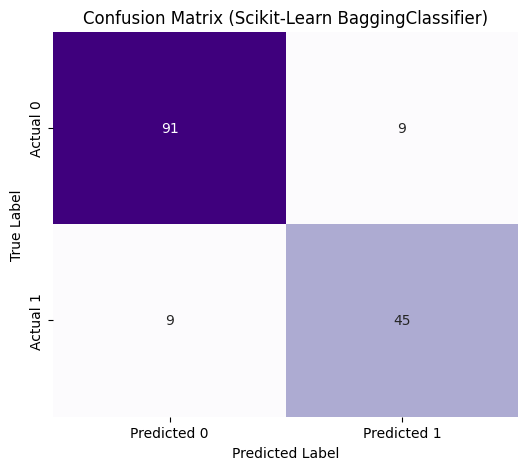

Accuracy (Scikit-Learn Bagging): 0.8831
Precision (Scikit-Learn Bagging): 0.8333
Recall (Scikit-Learn Bagging): 0.8333
F1-Score (Scikit-Learn Bagging): 0.8333

--- Comparison with Custom Bagging Implementation ---
Custom Bagging Accuracy: 0.9026
Scikit-Learn Bagging Accuracy: 0.8831
Difference in Accuracy (Custom - SKLearn): 0.0195


In [13]:
# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
#    Use DecisionTreeClassifier(max_depth=None) as the base estimator
#    and n_estimators=50 (same as our custom ensemble size).
bagging_sk = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42), # Use same random_state as single_tree_model for consistency if needed, or unique
    n_estimators=B, # Use the same B (50) as our custom implementation
    random_state=42 # For reproducibility of the Bagging process itself
)

# 2. Fit the classifier on the training set
bagging_sk.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_bagging_sk = bagging_sk.predict(X_test)

print("\n--- Performance of Scikit-Learn's BaggingClassifier ---")
# Calculate Confusion Matrix
cm_bagging_sk = confusion_matrix(y_test, y_pred_bagging_sk)
print("Confusion Matrix (Scikit-Learn Bagging):\n", cm_bagging_sk)

# Plot Confusion Matrix for Scikit-Learn's BaggingClassifier
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bagging_sk, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (Scikit-Learn BaggingClassifier)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate Accuracy
accuracy_bagging_sk = accuracy_score(y_test, y_pred_bagging_sk)
print(f"Accuracy (Scikit-Learn Bagging): {accuracy_bagging_sk:.4f}")

# Calculate Precision, Recall, F1-Score
precision_bagging_sk = precision_score(y_test, y_pred_bagging_sk)
recall_bagging_sk = recall_score(y_test, y_pred_bagging_sk)
f1_bagging_sk = f1_score(y_test, y_pred_bagging_sk)

print(f"Precision (Scikit-Learn Bagging): {precision_bagging_sk:.4f}")
print(f"Recall (Scikit-Learn Bagging): {recall_bagging_sk:.4f}")
print(f"F1-Score (Scikit-Learn Bagging): {f1_bagging_sk:.4f}")

print("\n--- Comparison with Custom Bagging Implementation ---")
print(f"Custom Bagging Accuracy: {accuracy_bagging:.4f}")
print(f"Scikit-Learn Bagging Accuracy: {accuracy_bagging_sk:.4f}")
print(f"Difference in Accuracy (Custom - SKLearn): {accuracy_bagging - accuracy_bagging_sk:.4f}")

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?